# <center>Rozwiązywanie układów równań</center>
# <center>Metody iteracyjne</center>

Instrukcja:
Na zajęciach należy wykonać poniższe zadania, a następnie sporządzić sprawozdanie zawierające odpowiedzi (w postaci kodu) z komentarzami w środowisku Jupyter Notebook i umieścić je na platformie e-learningowej.   

In [2]:
import main
import scipy as sp
import numpy as np
import scipy.sparse.linalg as sp_linalg
import numpy.linalg as np_linalg
import matplotlib
import matplotlib.pyplot as plt

In [3]:
def resid_norm(A,x,b):
    return np.linalg.norm(b-A@x)

**Cel zajęć:**  
Celem zajęć jest zapoznanie się z iteracyjnymi metodami rozwiązywania układów równań liniowych w postaci macierzowej. Metody iteracyjne, w przeciwieństwie do analitycznych, nie zwracają dokładnego rozwiązania, a jedynie jego przybliżenie. Przy spełnionych kryteriach, przybliżenia obliczane w kolejnych iteracjach są zbieżne do dokładnego rozwiązania. Metody iteracyjne znajdują swoje zastosowanie szczególnie przy dużych układach równań postaci: 
   
$
\mathbf{Ax}=\mathbf{b}
$ 
  
gdzie $\mathbf{A}$ to macierz współczynników z lewej strony równania, wektor $\mathbf{x}$ jest wektorem zmiennych a wektor $\mathbf{b}$ wyników prawej strony równania.  

Do oceny jakości rozwiązania będziemy wykorzystywać residuum (ang. *residual*)
$
\mathbf{r}=\mathbf{b}-\mathbf{Ax}
$ 
  

***Zadanie 1***   
Zdefiniuję funkcję *diag_dominant_matrix_A_b*, przyjmującą paramter całkowity $m>0$ która zwróci:
- macierz diagonalnie zdominowana $\mathbf{A}$ o wymiarach $m \times m$ (wyrazy na przekątnej sa wieksze co do modułu od sumy pozostałych w danej kolumnie i wierszu)
- wektor $\mathbf{b}$ o wymiarach $m \times 1$ 
 
o losowych wartościach całkowitych

Dodatkowo zdefiniuj funkcje *is_diag_dominant* sprawdzającą czy zadana macierz jest diagonalnie zdominowana

***Zadanie 2***   
Zdefiniuję funkcję *symmetric_matrix_A_b*, przyjmującą paramter całkowity $m>0$ która zwróci:
- symetryczną macierz $\mathbf{A}$ o wymiarach $m \times m$ (wyrazy symetryczne względnej przekątnej są sobie równe)
- wektor $\mathbf{b}$ o wymiarach $m \times 1$ 
 
o losowych wartościach całkowitych

Dodatkowo zdefiniuj funkcje is_symmetric sprawdzającą czy zadana macierz jest symetryczna

***Zadanie 3***   
Zdefiniuję następujące układy równań:

a) $\mathbf{A_1}$, $\mathbf{b_1}$: gdzie $\mathbf{A_1}$ jest macierzą o wymiarach $m \times m$, a $\mathbf{b_1}$ wektorem $m \times 1$, $m = 10$

b) $\mathbf{A_2}$, $\mathbf{b_2}$: gdzie $\mathbf{A_2}$ jest macierzą **diagonalnie zdominowaną** o wymiarach$m \times m$, a $\mathbf{b_2}$ wektorem $m \times 1$, $m = 10$
 
c) $\mathbf{A_3}$, $\mathbf{b_3}$: gdzie $\mathbf{A_3}$ jest macierzą **symetryczną** o wymiarach $m \times m$, a $\mathbf{b_3}$ wektorem $m \times 1$, $m = 10$   
 
**Wskazówka**: Do generacji macierzy użyj metody *random_matrix_Ab* z lab6 oraz metod *diag_dominant_matrix_A_b* i *symmetric_matrix_A_b*

In [4]:
a1,b1=main.random_matrix_Ab(10)
a2,b2=main.diag_dominant_matrix_A_b(10)
a3,b3=main.symmetric_matrix_A_b(10)

***Zadanie 4***   
Zaimplementuj iteracyjną metodę *solve_jacobi*, rozwiązującą układ równań metodą Jacobiego zgodnie z dokumentacją w pliku *main.py*.
Szczegóły metody zostały przedstawione na wykładzie.

***Zadanie 5***   
Rozwiąż układ równań z Zadania 3 podpunkt a) przy pomocy:

- funkcji *[solve](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.solve.html?highlight=solve#numpy.linalg.solve)* z biblioteki numpy

- zaimplementowanej iteracyjnej metody *solve_jacobi*

- iteracyjnej metody *[gradientów sprzężonych](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.cg.html)*
 z biblioteki scipy

- iteracyjnej metody *[GMRES](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.gmres.html)*
 z biblioteki scipy

Przed każdą metodą sprawdź czy warunki dotyczące macierzy dla danej metody są spełnione. Zbadaj dokładność i czas obliczeń metod w zależności od liczby iteracji. Wyniki przedstaw na wykresach.

dokładność solve() 5.756054031998179e-15
12 µs ± 4.98 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
Jakobi'm zajęłoby to nieskończoność
Gradient może zająć nieskończoność
zbieżność GRMES -  0


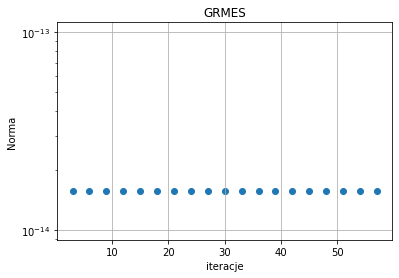

229 µs ± 24.5 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
262 µs ± 34.5 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
258 µs ± 10.5 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
230 µs ± 12.2 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
265 µs ± 46.7 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
222 µs ± 26 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
252 µs ± 9.21 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
261 µs ± 18.9 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
247 µs ± 21.7 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)


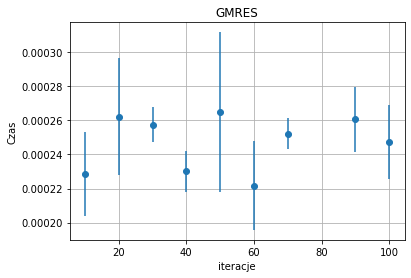

In [25]:
a,b=a1,b1
if a.shape[0]==a.shape[1]:
    result=np.linalg.solve(a,b)
    print("dokładność solve()",resid_norm(a,result,b))
    %timeit -r 5 -n 10 -o np.linalg.solve(a,b)
it  = [i+1 for i in range(57) if (i+1)%3==0]
x = np.zeros((10, 1))


if main.is_diag_dominant(a):
    err = []
    for i in it:
        s, iter = main.solve_jacobi(a, b, x, maxiter=i, epsilon=2.2e-16)
        err.append(resid_norm(a, s, b))
    plt.scatter(it, err)
    plt.yscale('log')
    plt.grid()
    plt.title("Jakobi")
    plt.xlabel("iteracje")
    plt.ylabel("Norma")
    plt.show()

    time=[]
    err=[]
    size=[10, 20, 30, 40, 50, 60, 70, 90, 100]
    x=np.zeros((10, 1))
    for i in size:
        avg=%timeit -r 5 -n 10 -o main.solve_jacobi(a, b,x_init, maxiter=i, epsilon=2.2e-16)
        time.append(avg.average)
        err.append(avg.stdev)

    plt.errorbar(size, time, yerr=err, linestyle="None", marker="o")
    plt.grid()
    plt.title("Jakobi")
    plt.xlabel("iteracje")
    plt.ylabel("Czas")

    plt.show()
else:
    print("Jakobi'm zajęłoby to nieskończoność")


if main.is_symmetric(a) and np.all(np.linalg.eigvals(a2) > 0):
    err = []
    for i in it:
        s,test=sp.sparse.linalg.cg(a, b, maxiter=i, atol=2.2e-16)
        err.append(resid_norm(a, s, b))
    print("zbieżność gradientu - ",test)
    plt.scatter(it, err)
    plt.yscale('log')
    plt.grid()
    plt.title("Gradient")
    plt.xlabel("iteracje")
    plt.ylabel("Norma")
    plt.show()

    time=[]
    err=[]
    size=[10, 20, 30, 40, 50, 60, 70, 90, 100]
    x=np.zeros((10, 1))
    for i in size:
        avg=%timeit -r 5 -n 10 -o sp.sparse.linalg.gmres(a, b, maxiter=i, atol=2.2e-16)
        time.append(avg.average)
        err.append(avg.stdev)

    plt.errorbar(size, time, yerr=err, linestyle="None", marker="o")
    plt.grid()
    plt.title("Gradient")
    plt.xlabel("iteracje")
    plt.ylabel("Czas")

    plt.show()
else:
    print("Gradient może zająć nieskończoność")


err = []
for i in it:
    s,test=sp.sparse.linalg.gmres(a, b, maxiter=i, atol=2.2e-16)
    err.append(resid_norm(a, s, b))
print("zbieżność GRMES - ",test)
plt.scatter(it, err)
plt.yscale('log')
plt.grid()
plt.title("GRMES")
plt.xlabel("iteracje")
plt.ylabel("Norma")
plt.show()

time=[]
err=[]
size=[10, 20, 30, 40, 50, 60, 70, 90, 100]
x=np.zeros((10, 1))
for i in size:
    avg=%timeit -r 5 -n 10 -o sp.sparse.linalg.gmres(a, b, maxiter=i, atol=2.2e-16)
    time.append(avg.average)
    err.append(avg.stdev)

plt.errorbar(size, time, yerr=err, linestyle="None", marker="o")
plt.grid()
plt.title("GMRES")
plt.xlabel("iteracje")
plt.ylabel("Czas")

plt.show()

***Zadanie 6***     
Rozwiąż układ równań z Zadania 3 podpunkt b) przy pomocy:

- funkcji *[solve](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.solve.html?highlight=solve#numpy.linalg.solve)* z biblioteki numpy

- zaimplementowanej iteracyjnej metody *solve_jacobi*

- iteracyjnej metody *[gradientów sprzężonych](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.cg.html)*
 z biblioteki scipy

- iteracyjnej metody *[GMRES](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.gmres.html)*
 z biblioteki scipy

Przed każdą metodą sprawdź czy warunki dotyczące macierzy dla danej metody są spełnione. Zbadaj dokładność i czas obliczeń metod w zależności od liczby iteracji. Wyniki przedstaw na wykresach.

dokładność solve() 4.864753555590494e-15
8.5 µs ± 1.99 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)


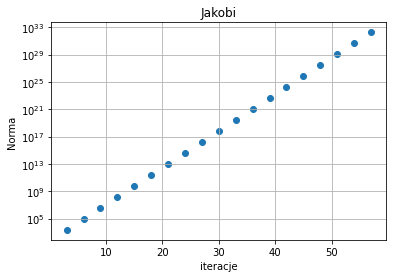

121 µs ± 19.2 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
215 µs ± 15.6 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
330 µs ± 28.7 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
397 µs ± 24.1 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
504 µs ± 31.6 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
569 µs ± 17 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
648 µs ± 13.8 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
829 µs ± 12.2 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
959 µs ± 32.1 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)


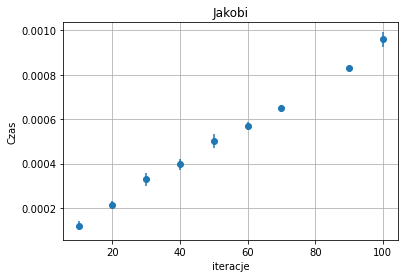

Gradient może zająć nieskończoność
zbieżność GRMES -  0


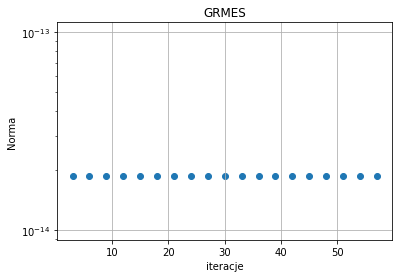

234 µs ± 6.4 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
237 µs ± 15.1 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
265 µs ± 18.9 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
253 µs ± 9.08 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
253 µs ± 23.2 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
250 µs ± 15.8 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
228 µs ± 44.7 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
241 µs ± 24.3 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
216 µs ± 12.1 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)


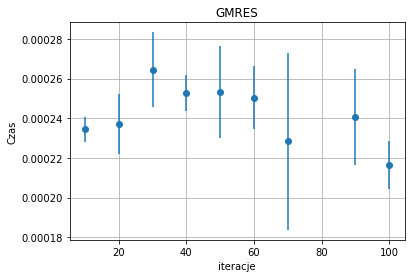

In [24]:
a=a2
b=b2
if a.shape[0]==a.shape[1]:
    result=np.linalg.solve(a,b)
    print("dokładność solve()",resid_norm(a,result,b))
    %timeit -r 5 -n 10 -o np.linalg.solve(a,b)
it  = [i+1 for i in range(57) if (i+1)%3==0]
x = np.zeros((10, 1))


if main.is_diag_dominant(a):
    err = []
    for i in it:
        s, ite= main.solve_jacobi(a, b, x,maxiter=i, epsilon=2.2e-16)
        err.append(resid_norm(a, s, b))
    plt.scatter(it, err)
    plt.yscale('log')
    plt.grid()
    plt.title("Jakobi")
    plt.xlabel("iteracje")
    plt.ylabel("Norma")
    plt.show()

    time=[]
    err=[]
    size=[10, 20, 30, 40, 50, 60, 70, 90, 100]
    x=np.zeros((10, 1))
    for i in size:
        avg=%timeit -r 5 -n 10 -o main.solve_jacobi(a, b,x, maxiter=i, epsilon=2.2e-16)
        time.append(avg.average)
        err.append(avg.stdev)

    plt.errorbar(size, time, yerr=err, linestyle="None", marker="o")
    plt.grid()
    plt.title("Jakobi")
    plt.xlabel("iteracje")
    plt.ylabel("Czas")

    plt.show()
else:
    print("Jakobi'm zajęłoby to nieskończoność")


if main.is_symmetric(a) and np.all(np.linalg.eigvals(a) > 0):
    err = []
    for i in it:
        s,test=sp.sparse.linalg.cg(a, b, maxiter=i, atol=2.2e-16)
        err.append(resid_norm(a, s, b))
    print("zbieżność gradientu - ",test)
    plt.scatter(it, err)
    plt.yscale('log')
    plt.grid()
    plt.title("Gradient")
    plt.xlabel("iteracje")
    plt.ylabel("Norma")
    plt.show()

    time=[]
    err=[]
    size=[10, 20, 30, 40, 50, 60, 70, 90, 100]
    x=np.zeros((10, 1))
    for i in size:
        avg=%timeit -r 5 -n 10 -o sp.sparse.linalg.gmres(a, b, maxiter=i, atol=2.2e-16)
        time.append(avg.average)
        err.append(avg.stdev)

    plt.errorbar(size, time, yerr=err, linestyle="None", marker="o")
    plt.grid()
    plt.title("Gradient")
    plt.xlabel("iteracje")
    plt.ylabel("Czas")

    plt.show()
else:
    print("Gradient może zająć nieskończoność")


err = []
for i in it:
    s,test=sp.sparse.linalg.gmres(a, b, maxiter=i, atol=2.2e-16)
    err.append(resid_norm(a, s, b))
print("zbieżność GRMES - ",test)
plt.scatter(it, err)
plt.yscale('log')
plt.grid()
plt.title("GRMES")
plt.xlabel("iteracje")
plt.ylabel("Norma")
plt.show()

time=[]
err=[]
size=[10, 20, 30, 40, 50, 60, 70, 90, 100]
x=np.zeros((10, 1))
for i in size:
    avg=%timeit -r 5 -n 10 -o sp.sparse.linalg.gmres(a, b, maxiter=i, atol=2.2e-16)
    time.append(avg.average)
    err.append(avg.stdev)

plt.errorbar(size, time, yerr=err, linestyle="None", marker="o")
plt.grid()
plt.title("GMRES")
plt.xlabel("iteracje")
plt.ylabel("Czas")

plt.show()

***Zadanie 7***   
Rozwiąż układ równań z Zadania 3 podpunkt c) przy pomocy:

- funkcji *[solve](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.solve.html?highlight=solve#numpy.linalg.solve)* z biblioteki numpy

- zaimplementowanej iteracyjnej metody *solve_jacobi*

- iteracyjnej metody *[gradientów sprzężonych](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.cg.html)*
 z biblioteki scipy

- iteracyjnej metody *[GMRES](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.gmres.html)*
 z biblioteki scipy

Przed każdą metodą sprawdź czy warunki dotyczące macierzy dla danej metody są spełnione. Zbadaj dokładność i czas obliczeń metod w zależności od liczby iteracji. Wyniki przedstaw na wykresach.

dokładność solve() 82.14851214513318
Jakobi'm zajęłoby to nieskończoność
zbieżność gradientu -  0


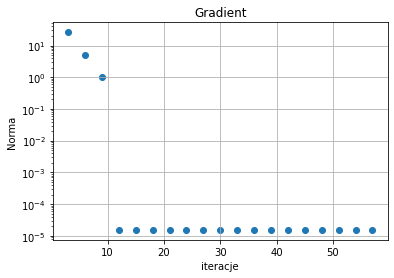

262 µs ± 12.5 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
296 µs ± 76.2 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
227 µs ± 9.98 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
216 µs ± 5.98 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
226 µs ± 11.2 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
223 µs ± 7.92 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
224 µs ± 5.18 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
225 µs ± 8.23 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
220 µs ± 2.89 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)


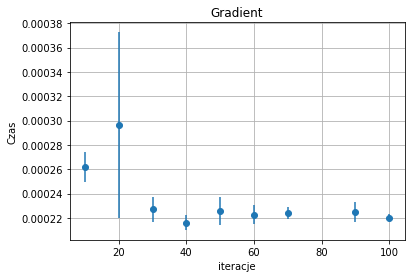

zbieżność GRMES -  0


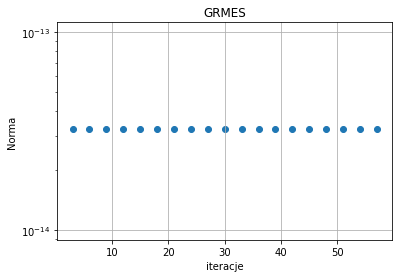

229 µs ± 33.9 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
240 µs ± 33.5 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
241 µs ± 25.7 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
234 µs ± 15.7 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
228 µs ± 9.79 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
238 µs ± 2.08 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
232 µs ± 9.21 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
227 µs ± 4.87 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)
222 µs ± 8.75 µs per loop (mean ± std. dev. of 5 runs, 10 loops each)


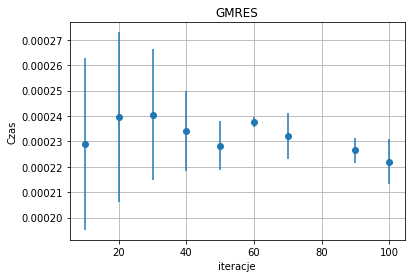

In [7]:
a,b=a3,b3
if a.shape[0]==a.shape[1]:
    result=np.linalg.solve(a,b)
    print("dokładność solve()",resid_norm(a1,result,b))
    %timeit -r 5 -n 10 -o np.linalg.solve(a,b)
it  = [i+1 for i in range(57) if (i+1)%3==0]
x = np.zeros((10, 1))


if main.is_diag_dominant(a):
    err = []
    for i in it:
        s, iter = main.solve_jacobi(a, b, x, maxiter=i, epsilon=2.2e-16)
        err.append(resid_norm(a, s, b))
    plt.scatter(it, err)
    plt.yscale('log')
    plt.grid()
    plt.title("Jakobi")
    plt.xlabel("iteracje")
    plt.ylabel("Norma")
    plt.show()

    time=[]
    err=[]
    size=[10, 20, 30, 40, 50, 60, 70, 90, 100]
    x=np.zeros((10, 1))
    for i in size:
        avg=%timeit -r 5 -n 10 -o main.solve_jacobi(a, b,x_init, maxiter=i, epsilon=2.2e-16)
        time.append(avg.average)
        err.append(avg.stdev)

    plt.errorbar(size, time, yerr=err, linestyle="None", marker="o")
    plt.grid()
    plt.title("Jakobi")
    plt.xlabel("iteracje")
    plt.ylabel("Czas")

    plt.show()
else:
    print("Jakobi'm zajęłoby to nieskończoność")


if main.is_symmetric(a) and np.all(np.linalg.eigvals(a2) > 0):
    err = []
    for i in it:
        s,test=sp.sparse.linalg.cg(a, b, maxiter=i, atol=2.2e-16)
        err.append(resid_norm(a, s, b))
    print("zbieżność gradientu - ",test)
    plt.scatter(it, err)
    plt.yscale('log')
    plt.grid()
    plt.title("Gradient")
    plt.xlabel("iteracje")
    plt.ylabel("Norma")
    plt.show()

    time=[]
    err=[]
    size=[10, 20, 30, 40, 50, 60, 70, 90, 100]
    x=np.zeros((10, 1))
    for i in size:
        avg=%timeit -r 5 -n 10 -o sp.sparse.linalg.gmres(a, b, maxiter=i, atol=2.2e-16)
        time.append(avg.average)
        err.append(avg.stdev)

    plt.errorbar(size, time, yerr=err, linestyle="None", marker="o")
    plt.grid()
    plt.title("Gradient")
    plt.xlabel("iteracje")
    plt.ylabel("Czas")

    plt.show()
else:
    print("Gradient może zająć nieskończoność")


err = []
for i in it:
    s,test=sp.sparse.linalg.gmres(a, b, maxiter=i, atol=2.2e-16)
    err.append(resid_norm(a, s, b))
print("zbieżność GRMES - ",test)
plt.scatter(it, err)
plt.yscale('log')
plt.grid()
plt.title("GRMES")
plt.xlabel("iteracje")
plt.ylabel("Norma")
plt.show()

time=[]
err=[]
size=[10, 20, 30, 40, 50, 60, 70, 90, 100]
x=np.zeros((10, 1))
for i in size:
    avg=%timeit -r 5 -n 10 -o sp.sparse.linalg.gmres(a, b, maxiter=i, atol=2.2e-16)
    time.append(avg.average)
    err.append(avg.stdev)

plt.errorbar(size, time, yerr=err, linestyle="None", marker="o")
plt.grid()
plt.title("GMRES")
plt.xlabel("iteracje")
plt.ylabel("Czas")

plt.show()

Materiały uzupełniające:
- [Scipy Lecture Notes](http://www.scipy-lectures.org/index.html)
- [NumPy for Matlab users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#numpy-for-matlab-users)
- [Python Tutorial - W3Schools](https://www.w3schools.com/python/default.asp)
- [NumPy](https://www.numpy.org)
- [Matplotlib](https://matplotlib.org/)
- [Anaconda](https://www.anaconda.com/)
- [Learn Python for Data Science](https://www.datacamp.com/learn-python-with-anaconda?utm_source=Anaconda_download&utm_campaign=datacamp_training&utm_medium=banner)
- [Learn Python](https://www.learnpython.org/)
- [Wujek Google](https://google.pl) i [Ciocia Wikipedia](https://pl.wikipedia.org/wiki/Wikipedia:Strona_g%C5%82%C3%B3wna)